import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Grid Parameters (A 2-meter long domain)
nx = 81          # Number of grid nodes
dx = 2 / (nx-1)  # Space step size
nt = 25          # Number of time steps
dt = .02         # Time step size
c = 1            # Constant wave speed velocity

# 2. Set Initial Conditions (A square velocity surge)
u = np.ones(nx)      
u[int(.5/dx):int(1/dx + 1)] = 2.0  # Wave spike between x = 0.5m and 1.0m

# Plot the starting shape of the fluid wave
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0, 2, nx), u, label="Initial Wave Profile")

# 3. The Core CFD Solver: Vectorized Array Slicing
for n in range(nt):
    un = u.copy()
    u[1:] = un[1:] - c * dt / dx * (un[1:] - un[:-1])

# Plot the finished wave shape after moving over time
plt.plot(np.linspace(0, 2, nx), u, 'r--', label=f"Convected Wave (t={nt*dt}s)")
plt.xlabel("Spatial Grid Coordinates (x)")
plt.ylabel("Fluid Velocity (u)")
plt.title("1D Linear Convection Finite Difference Mesh Simulation")
plt.legend()
plt.show()


import os
import ansys.fluent.core as pyfluent

# 1. Force the system to bypass watchdog network exceptions
os.environ["PYFLUENT_WATCHDOG_EXCEPTION_ON_ERROR"] = "0"

print("--- Initializing Secure Fluent Session ---")

try:
    # 2. Launch with a slower server start timeout configuration
    session = pyfluent.launch_fluent(
        precision="double", 
        processor_count=2,
        start_timeout=60,      # Gives your laptop 60 seconds to open the backend 
        cleanup_on_exit=True   # Automatically clears memory if it stalls
    )
    
    print("\n🎉 SUCCESS! Connected to Fluent Engine.")
    print(f"Active Version: {session.get_fluent_version()}")
    
    # 3. Safely disconnect 
    session.exit()
    print("Session closed down cleanly.")

except Exception as e:
    print(f"\n⚠️ System check completed. If it still pauses, run the unlock script below: {e}")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clear any stuck hidden processes first
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

print("--- Launching Visual Graphical Session ---")

try:
    # 2. Set 'show_gui=True' to open Fluent in standard app mode
    session = pyfluent.launch_fluent(
        precision="double", 
        processor_count=2,
        show_gui=True,        # FORCES the full visual interface window to appear
        start_timeout=120     # Gives your laptop 2 full minutes to load it
    )
    
    print("\n🎉 SUCCESS! Connected to Fluent Engine.")
    print(f"Active Version: {session.get_fluent_version()}")
    
    # 3. Clean exit
    session.exit()
    print("Session closed down cleanly.")

except Exception as e:
    print(f"\n⚠️ Still blocked? Run the Administrator access check below. Error trace: {e}")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clear memory loops
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Start your active visual session
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=2,
    ui_mode="graphic"  # Using the updated syntax to avoid the pink warning!
)

print("\n--- 🟢 Fluent Session Live ---")

# 3. HOW TO READ A SIMULATION FILE
# Replace the file path below with the location of any Fluent .cas file on your laptop
try:
    print("Ready to load your file... To run a case, uncomment and update the path below:")
    # session.tui.file.read_case(r"C:\Users\Lenovo\Documents\your_simulation.cas.h5")
    
    print("\n--- 📂 Available Sub-Menu Commands for Your Setup ---")
    print(dir(session.setup))
    
except Exception as e:
    print(f"Error loading file: {e}")

# 4. Keep it open or close it
session.exit()
print("\nSession finished and closed down safely.")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clear memory loops
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Start your active session using the supported string 'gui'
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=2,
    ui_mode="gui"  # CHANGED: 'graphic' corrected to 'gui'
)

print("\n--- 🟢 Fluent Session Live ---")

# 3. Explore available commands
try:
    print("\n--- 📂 Available Sub-Menu Commands for Your Setup ---")
    print(dir(session.setup))
    
except Exception as e:
    print(f"Error inspecting setup: {e}")

# 4. Clean exit
session.exit()
print("\nSession finished and closed down safely.")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clean background memory
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Launch your visual Fluent session
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=2,
    ui_mode="gui"
)

print("\n--- 🌐 Connected Live to Fluent Settings Tree ---")

try:
    # 3. Use the updated 'settings.setup' path requested by the warning
    bc_dir = dir(session.settings.setup.boundary_conditions)
    print("\n✅ Successfully entered Boundary Conditions folder structure!")
    
    print("\n--- 📂 Available BC Automations ---")
    # This will show things like 'velocity_inlet', 'pressure_outlet', 'wall', etc.
    for item in bc_dir:
        if not item.startswith("_"): # Clean up hidden internal code items
            print(f"👉 session.settings.setup.boundary_conditions.{item}")

except Exception as e:
    print(f"⚠️ Navigation check error: {e}")

# 4. Safely exit
session.exit()
print("\nSession finished and memory cleaned.")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clean background tasks
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Launch your session (using 4 cores now since your license allows it!)
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=4, 
    ui_mode="gui"
)

print("\n--- 🟢 Testing Live Modification ---")

try:
    # 3. Change gravity using the official settings path
    print("Commanding Fluent to turn on vertical gravity...")
    session.settings.setup.general.gravity = {
        "status": True,
        "v": [0, -9.81, 0]  # Sets gravity pointing downwards on the Y-axis
    }
    print("✅ Gravity successfully altered via Python code!")
    
    # 4. Verify that Fluent updated the value
    current_gravity = session.settings.setup.general.gravity.v()
    print(f"Verified current solver gravity: {current_gravity}")

except Exception as e:
    print(f"⚠️ Operation note: {e}")

# 5. Cleanly shut down
session.exit()
print("\nSession completed successfully.")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clean background tasks
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Launch your session using 4 cores
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=4, 
    ui_mode="gui"
)

print("\n--- 🟢 Testing Live Modification ---")

try:
    # 3. Change gravity using the updated 'operating_conditions' path
    print("Commanding Fluent to turn on vertical gravity...")
    session.settings.setup.operating_conditions.gravity = {
        "status": True,
        "v": [0, -9.81, 0]  # Sets gravity pointing downwards on the Y-axis
    }
    print("✅ Gravity successfully altered via Python code!")
    
    # 4. Verify that Fluent updated the value
    current_gravity = session.settings.setup.operating_conditions.gravity.v()
    print(f"Verified current solver gravity: {current_gravity}")

except Exception as e:
    print(f"⚠️ Operation note: {e}")

# 5. Cleanly shut down
session.exit()
print("\nSession completed successfully.")


In [ ]:
import os
import ansys.fluent.core as pyfluent

# Clean background memory
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

session = pyfluent.launch_fluent(precision="double", processor_count=4, ui_mode="gui")

print("--- 🔍 Searching for 'gravity' or 'operating_conditions' ---")
try:
    # 1. Check if it's sitting inside cell_zone_conditions as suggested by Fluent
    print("\nChecking cell_zone_conditions attributes:")
    print([item for item in dir(session.settings.setup.cell_zone_conditions) if not item.startswith("_")])
    
    # 2. Check the main top-level settings attributes
    print("\nChecking top-level settings attributes:")
    print([item for item in dir(session.settings) if not item.startswith("_")])

except Exception as e:
    print(f"Error searching: {e}")

session.exit()


In [ ]:
import os
import ansys.fluent.core as pyfluent

# 1. Clean background tasks from memory
os.system("taskkill /f /im fluent.exe /t")
os.system("taskkill /f /im cortex.exe /t")

# 2. Launch your session using 4 cores
session = pyfluent.launch_fluent(
    precision="double", 
    processor_count=4, 
    ui_mode="gui"
)

print("\n--- 🟢 Modifying Fluent via the 2026 Design Module ---")

try:
    # 3. Direct path using the new top-level 'design' module
    print("Commanding Fluent to activate gravity vector fields...")
    session.settings.design.operating_conditions.gravity = {
        "status": True,
        "v": [0, -9.81, 0]  # Sets gravity pointing downwards on the Y-axis
    }
    print("✅ Gravity successfully altered via Python code!")
    
    # 4. Verify that Fluent updated the numerical array value
    current_gravity = session.settings.design.operating_conditions.gravity.v()
    print(f"Verified current solver gravity coordinates: {current_gravity}")

except Exception as e:
    print(f"⚠️ Operation note: {e}")
    print("\nIf it still pauses, let's list the internal folders inside design:")
    try:
        print(dir(session.settings.design))
    except:
        pass

# 5. Cleanly shut down the background GUI app instance
session.exit()
print("\nSession completed successfully and memory flushed.")


In [ ]:
%pip install pyaedt pymechanical


In [ ]:
%pip install pyaedt ansys-mechanical-core


In [ ]:
import pyaedt
import ansys.mechanical.core as pymechanical

print("PyAEDT Version:", pyaedt.__version__)
print("PyMechanical Version:", pymechanical.__version__)


In [ ]:
import sys
!{sys.executable} -m pip install pyaedt ansys-mechanical-core


In [ ]:
!where python


In [ ]:
!dir "C:\Program Files\Ansys Inc"


In [ ]:
!dir "C:\Program Files\Ansys Inc\ANSYS Student"


In [ ]:
!"C:\Program Files\Ansys Inc\ANSYS Student\v261\common files\CPython\3_10\winx64\Release\python.exe" -m pip install pyaedt ansys-mechanical-core


In [ ]:
!dir "C:\Program Files\Ansys Inc\ANSYS Student\v261\common files"


In [ ]:
!dir "C:\Program Files\Ansys Inc\ANSYS Student\v261" /s /b | findstr /i "python.exe"


In [ ]:
import subprocess
import sys

# Force-install compatible versions directly into your working environment
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pyaedt", "ansys-mechanical-core", "pythonnet", "pywin32"])
print("Installation update complete!")


In [ ]:
import pyaedt
import ansys.mechanical.core as pymechanical

print("Success! PyAEDT version:", pyaedt.__version__)
print("Success! PyMechanical version:", pymechanical.__version__)


In [ ]:
import pyaedt
import ansys.mechanical.core as pymechanical


In [ ]:
%pip install pyaedt ansys-mechanical-core


In [3]:
%pip install pyaedt ansys-mechanical-core


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import subprocess

# Define the path to your Ansys Student Mechanical automation executable
mechanical_exe = r"C:\Program Files\Ansys Inc\ANSYS Student\v261\aisol\bin\winx64\AnsysMechanical.exe"

# Launch an independent background automated instance
if os.path.exists(mechanical_exe):
    print("Launching independent Mechanical instance... please check your Windows taskbar!")
    subprocess.Popen([mechanical_exe, "-gRPC"])
else:
    print("Executable path not found. Let's find your correct folder location.")


Executable path not found. Let's find your correct folder location.


In [5]:
import os
import subprocess

# Scan your Ansys Student directory to find the mechanical executable file path automatically
base_search_dir = r"C:\Program Files\Ansys Inc\ANSYS Student"
found_path = None

for root, dirs, files in os.walk(base_search_dir):
    if "AnsysMechanical.exe" in files:
        found_path = os.path.join(root, "AnsysMechanical.exe")
        break

if found_path:
    print(f"Found Mechanical at: {found_path}")
    print("Launching independent Mechanical instance... Check your taskbar!")
    subprocess.Popen([found_path, "-gRPC"])
else:
    print("Could not find AnsysMechanical.exe in the default Student folder directory.")


Could not find AnsysMechanical.exe in the default Student folder directory.


In [6]:
import os
import subprocess

base_search_dir = r"C:\Program Files\Ansys Inc\ANSYS Student"
found_path = None

# Scan everything checking file names in lower-case to prevent case mismatches
for root, dirs, files in os.walk(base_search_dir):
    for f in files:
        if f.lower() == "ansysmechanical.exe":
            found_path = os.path.join(root, f)
            break
    if found_path:
        break

if found_path:
    print(f"Found Mechanical at: {found_path}")
    print("Launching independent Mechanical instance... Watch your taskbar!")
    subprocess.Popen([found_path, "-gRPC"])
else:
    print("Could not find the executable. Let's list your main directories to see what is inside.")


Could not find the executable. Let's list your main directories to see what is inside.


In [7]:
import os

# Check your newest v261 installation directory for any executable apps
v261_dir = r"C:\Program Files\Ansys Inc\ANSYS Student\v261"
exe_files = []

if os.path.exists(v261_dir):
    for root, dirs, files in os.walk(v261_dir):
        # Only check the first few main folders so it doesn't take too long
        if len(exe_files) > 15: 
            break
        for f in files:
            if f.endswith(".exe") and "mechanical" in f.lower():
                exe_files.append(os.path.join(root, f))

    print("--- Found Mechanical Executables ---")
    for path in exe_files:
        print(path)
else:
    print("v261 directory path not found.")


--- Found Mechanical Executables ---
C:\Program Files\Ansys Inc\ANSYS Student\v261\ansys\MaterialCalibration\fitter\server\bin\ansys.mechanical.material_calibration.server.exe


In [8]:
import os

# Check your core v252 installation directory for the automation file
v252_dir = r"C:\Program Files\Ansys Inc\ANSYS Student\v252"
exe_files = []

if os.path.exists(v252_dir):
    for root, dirs, files in os.walk(v252_dir):
        if len(exe_files) > 10: 
            break
        for f in files:
            if f.endswith(".exe") and "mechanical" in f.lower():
                exe_files.append(os.path.join(root, f))

    print("--- Found Mechanical Executables in v252 ---")
    for path in exe_files:
        print(path)
else:
    print("v252 directory folder path not found on this computer.")


--- Found Mechanical Executables in v252 ---
C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\MECHANICALCOMENGINE.exe


In [9]:
import subprocess

# Define the exact path we discovered
target_exe = r"C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\MECHANICALCOMENGINE.exe"

print("Launching the AnsysEM Mechanical Engine... Check your Windows taskbar!")
# Launch the application in automation mode
subprocess.Popen([target_exe])


Launching the AnsysEM Mechanical Engine... Check your Windows taskbar!


<Popen: returncode: None args: ['C:\\Program Files\\Ansys Inc\\ANSYS Student...>

In [10]:
import os
import subprocess

# Define the path to the primary visual AEDT desktop application
aedt_exe = r"C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\Win64\ansysedt.exe"

if os.path.exists(aedt_exe):
    print("Launching Ansys Electronics Desktop Student... Watch your screen!")
    # Start the desktop app in interactive mode
    subprocess.Popen([aedt_exe])
else:
    print("AEDT executable not found in v252. Let's try searching your v261 directory.")


AEDT executable not found in v252. Let's try searching your v261 directory.


In [11]:
import os
import subprocess

base_search_dir = r"C:\Program Files\Ansys Inc\ANSYS Student"
found_aedt = None

# Scan everything checking for ansysedt.exe in lower-case
for root, dirs, files in os.walk(base_search_dir):
    for f in files:
        if f.lower() == "ansysedt.exe":
            found_aedt = os.path.join(root, f)
            break
    if found_aedt:
        break

if found_aedt:
    print(f"Found AEDT at: {found_aedt}")
    print("Launching Ansys Electronics Desktop Student... Watch your screen!")
    subprocess.Popen([found_aedt])
else:
    print("Could not find ansysedt.exe in the default Student folder directory.")


Could not find ansysedt.exe in the default Student folder directory.


In [12]:
import os

base_search_dir = r"C:\Program Files\Ansys Inc\ANSYS Student"
found_apps = []

if os.path.exists(base_search_dir):
    for root, dirs, files in os.walk(base_search_dir):
        # Limit results so the screen doesn't overflow
        if len(found_apps) > 20:
            break
        for f in files:
            if f.endswith(".exe") and ("fluent" in f.lower() or "workbench" in f.lower() or "scdm" in f.lower()):
                found_apps.append(os.path.join(root, f))

    print("--- Found Active Ansys Executables ---")
    for app in found_apps:
        print(app)
else:
    print("Ansys Student main folder not found.")


--- Found Active Ansys Executables ---
C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\common\ACT\bin\Win64\Ansys.ACT.Fluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\fluent\ntbin\win64\fluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v252\AnsysEM\fluent\ntbin\win64\fluent_aeneid.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\Addins\ACT\bin\Win64\Ansys.ACT.Fluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\aisol\bin\winx64\fluent6.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\aisol\bin\winx64\readfluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\CFD-Post\bin\winnt-amd64\ImportFluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\CFX\bin\winnt-amd64\ImportFluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\commonfiles\CFX\bin\winnt-amd64\ImportFluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\fensapice\bin\fensap2fluent.exe
C:\Program Files\Ansys Inc\ANSYS Student\v261\fensapice\bin\fluent2fensap.exe
C:\Program Files\Ansys Inc\

In [13]:
import os

# Scan your local user app data folder for the hidden 2025 R2 student installer
user_home = os.path.expanduser("~")
search_root = os.path.join(user_home, "AppData", "Local", "AnsysEM")
found_exe = None

if os.path.exists(search_root):
    for root, dirs, files in os.walk(search_root):
        if "ansysedt.exe" in files:
            found_exe = os.path.join(root, "ansysedt.exe")
            break

if found_exe:
    print(f"--- PATH FOUND SUCCESSFULLY! ---")
    print(found_exe)
else:
    # Try an alternative broad user-profile scan
    for root, dirs, files in os.walk(os.path.join(user_home, "AppData")):
        if "ansysedt.exe" in files:
            found_exe = os.path.join(root, "ansysedt.exe")
            print(f"--- PATH FOUND IN ALTERNATIVE FOLDER! ---")
            print(found_exe)
            break


In [14]:
import psutil

print("Scanning running system memory for Ansys Electronics Desktop...")
found = False

# Search active Windows processes to pull the exact running file path
for proc in psutil.process_iter(['name', 'exe']):
    try:
        if proc.info['name'] and 'ansysedt' in proc.info['name'].lower():
            print("\n--- TARGET PATH LOCATED! ---")
            print(f"Your absolute executable path is:\n{proc.info['exe']}")
            found = True
            break
    except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
        pass

if not found:
    print("\nCould not read process path directly. Try opening a new blank project in AEDT first, then rerun this cell!")


Scanning running system memory for Ansys Electronics Desktop...

--- TARGET PATH LOCATED! ---
Your absolute executable path is:
C:\Program Files\ANSYS Inc\ANSYS Student\v252\AnsysEM\ansysedtsv.exe


In [15]:
import win32com.client

try:
    # 1. Connect directly to your open AEDT instance in memory
    oAnsysApp = win32com.client.Dispatch("Ansoft.ElectronicsDesktop")
    print("Successfully connected to your open AEDT instance!")
    
    # 2. Get the active desktop workspace
    oDesktop = oAnsysApp.GetAppDesktop()
    
    # 3. Create a brand new project and insert a design
    # Change "HFSS" to "Maxwell 3D" or "Q3D" depending on what you want to build!
    oProject = oDesktop.NewProject()
    oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
    
    print("Success! Look at your AEDT window—a new project has been created dynamically.")

except Exception as e:
    print("Connection failed. Make sure AEDT is actively open on your screen and try again!")
    print(f"Error details: {e}")


Connection failed. Make sure AEDT is actively open on your screen and try again!
Error details: (-2147221005, 'Invalid class string', None, None)


In [16]:
import win32com.client

try:
    # 1. Connect directly to your open AEDT instance in memory
    oAnsysApp = win32com.client.Dispatch("Ansoft.ElectronicsDesktop")
    print("Successfully connected to your open AEDT instance!")
    
    # 2. Get the active desktop workspace
    oDesktop = oAnsysApp.GetAppDesktop()
    
    # 3. Create a brand new project and insert a design
    # Change "HFSS" to "Maxwell 3D" or "Q3D" depending on what you want to build!
    oProject = oDesktop.NewProject()
    oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
    
    print("Success! Look at your AEDT window—a new project has been created dynamically.")

except Exception as e:
    print("Connection failed. Make sure AEDT is actively open on your screen and try again!")
    print(f"Error details: {e}")


Connection failed. Make sure AEDT is actively open on your screen and try again!
Error details: (-2147221005, 'Invalid class string', None, None)


In [17]:
import win32com.client

oAnsysApp = None

# List of all possible student registry strings for 2025 R2 Student Edition
student_identifiers = [
    "Ansoft.ElectronicsDesktop.25.2",
    "Ansoft.ElectronicsDesktopStudent",
    "Ansoft.ElectronicsDesktop"
]

for identifier in student_identifiers:
    try:
        print(f"Trying to connect using: {identifier}...")
        oAnsysApp = win32com.client.Dispatch(identifier)
        print(f"--- SUCCESS! Connected using {identifier} ---")
        break
    except Exception:
        continue

if oAnsysApp:
    try:
        oDesktop = oAnsysApp.GetAppDesktop()
        oProject = oDesktop.NewProject()
        # Inserts a standard HFSS design workspace
        oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
        print("\nSuccess! Check your AEDT window—a new project has been created dynamically.")
    except Exception as e:
        print(f"App connected, but failed to create design: {e}")
else:
    print("\nAll connection identifiers failed. Let's register your student client directly.")


Trying to connect using: Ansoft.ElectronicsDesktop.25.2...
Trying to connect using: Ansoft.ElectronicsDesktopStudent...
Trying to connect using: Ansoft.ElectronicsDesktop...

All connection identifiers failed. Let's register your student client directly.


In [18]:
import win32com.client

try:
    # Now that the system keys are repaired, this baseline key will find the student version cleanly
    oAnsysApp = win32com.client.Dispatch("Ansoft.ElectronicsDesktop")
    print("--- SUCCESS! Connected to Ansys Electronics Desktop Student ---")
    
    oDesktop = oAnsysApp.GetAppDesktop()
    oProject = oDesktop.NewProject()
    oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
    print("Success! Check your AEDT window—a new project has been created dynamically.")
except Exception as e:
    print(f"Connection failed: {e}")


Connection failed: (-2147221005, 'Invalid class string', None, None)


In [19]:
import win32com.client
import sys

try:
    # 1. Look up the running application directly in the system's active object table
    oAnsysApp = win32com.client.GetObject(None, "Ansoft.ElectronicsDesktop")
    print("--- SUCCESS: Hooked into your running AEDT session! ---")
    
    # 2. Grab the active desktop and create your project
    oDesktop = oAnsysApp.GetAppDesktop()
    oProject = oDesktop.NewProject()
    oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
    print("Check your AEDT window—a new project has been created dynamically!")

except Exception as e:
    # 2. Try an alternative direct object identifier check if the first fails
    try:
        oAnsysApp = win32com.client.GetObject(Class="Ansoft.ElectronicsDesktop")
        oDesktop = oAnsysApp.GetAppDesktop()
        oProject = oDesktop.NewProject()
        oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
        print("--- SUCCESS! Connected via secondary object hook. ---")
    except Exception as e2:
        print("Direct memory connection failed.")
        print(f"Details: {e2}")


Direct memory connection failed.
Details: (-2147221005, 'Invalid class string', None, None)


In [20]:
script_content = """
import ScriptEnv
ScriptEnv.Initialize("Ansoft.ElectronicsDesktop")
oDesktop.RestoreWindow()

# 1. Create a brand new project
oProject = oDesktop.NewProject()

# 2. Insert an HFSS automated design layout
oProject.InsertDesign("HFSS", "Automated_Design", "DrivenTerminal", "")
"""

# Write this script directly to your C: drive folder
with open(r"C:\Users\Lenovo\Desktop\run_aedt.py", "w") as f:
    f.write(script_content.strip())

print("Success! The script 'run_aedt.py' has been saved directly to your Desktop.")


Success! The script 'run_aedt.py' has been saved directly to your Desktop.


In [21]:
import os

# 1. Locate the official Ansys Fluent preferences directory on Windows
user_profile = os.environ.get("USERPROFILE")
preferences_path = os.path.join(user_profile, ".fluent", "fluent_preferences.xml")

print(f"Targeting preferences file: {preferences_path}")

# 2. Check if the file exists and update the font configuration line directly
if os.path.exists(preferences_path):
    with open(preferences_path, "r", encoding="utf-8") as file:
        content = file.read()
    
    # Force replace any default font sizes with the optimized laptop size 10
    if "ApplicationFontSize" in content:
        # Simple string replace trick to update the inner value tag
        import re
        updated_content = re.sub(r'<ApplicationFontSize.*?>.*?</ApplicationFontSize>', 
                                 '<ApplicationFontSize type="int">10</ApplicationFontSize>', content)
        
        with open(preferences_path, "w", encoding="utf-8") as file:
            file.write(updated_content)
        print("--- SUCCESS: Settings file updated to Font Size 10! ---")
    else:
        print("Font configuration tag not initialized yet. Launch and close Fluent once to generate it.")
else:
    # If the file folder doesn't exist yet, we can create a clean base configuration directory
    os.makedirs(os.path.dirname(preferences_path), exist_ok=True)
    base_config = '<FluentPreferences><ApplicationFontSize type="int">10</ApplicationFontSize></FluentPreferences>'
    with open(preferences_path, "w", encoding="utf-8") as file:
        file.write(base_config)
    print("--- SUCCESS: Fresh Font Size 10 configuration file injected! ---")


Targeting preferences file: C:\Users\Lenovo\.fluent\fluent_preferences.xml
--- SUCCESS: Fresh Font Size 10 configuration file injected! ---


In [22]:
pip install modulus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for modulus: filename=modulus-0.0.10a0-py3-none-any.whl size=1793 sha256=eaeaf23a83b04213b8f97be9efbc8c3ef1db4906cab90e5895a1e1a71920a7e9
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\6f\2f\80\11964a10c30407feb7cfbbe0ad1f4fd3052659deba1e64acdd
Successfully built modulus
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
%pip install torch torchvision torchaudio --index-url 

Note: you may need to restart the kernel to use updated packages.



[optparse.groups]Usage:[/]   
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] <requirement specifier> \[package-index-options] ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] -r <requirements file> \[package-index-options] ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] [-e] <vcs project url> ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] [-e] <local project path> ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [24]:
https://pytorch.org

SyntaxError: invalid syntax (1488691599.py, line 1)

In [25]:
pip install torch torchvision torchaudio --index-url 

Note: you may need to restart the kernel to use updated packages.



[optparse.groups]Usage:[/]   
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] <requirement specifier> \[package-index-options] ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] -r <requirements file> \[package-index-options] ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] [-e] <vcs project url> ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] [-e] <local project path> ...
  C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [26]:
https://pytorch.org

SyntaxError: invalid syntax (1488691599.py, line 1)

In [27]:
!pip install torch torchvision torchaudio --index-url https://pytorch.org

Looking in indexes: https://pytorch.org


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [28]:
!pip install torch torchvision torchaudio --index-url 


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [29]:
!pip install torch torchvision torchaudio --index-url 


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [30]:
!pip install torch torchvision torchaudio --index-url 


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

--index-url option requires 1 argument


In [31]:
!pip install torch


  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 12.7 MB/s eta 0:00:10
   ---------------------------------------- 1.0/122.1 MB 2.0 MB/s eta 0:01:00
    --------------------------------------- 1.6/122.1 MB 2.1 MB/s eta 0:00:57
    --------------------------------------- 2.1/122.1 MB 2.1 MB/s eta 0:00:57
    --------------------------------------- 2.6/122.1 MB 2.2 MB/s eta 0:00:54
   - -------------------------------------- 3.4/122.1 MB 2.5 MB/s eta 0:00:48
   - -------------------------------------- 3.9/122.1 MB 2.5 MB/s eta 0:00:48
   - -------------------------------------- 4.7/122.1 MB 2.7 MB/s eta 0:00:45
   - -------------------------------------- 5.2/122.1 MB 2.7 MB/s eta 0:00:44
   - -------------------------------------- 5.8/122.1 MB 2.6 MB/s eta 0:00:45
   -- ------------------------------------- 6.8/122.1 MB 2.8 MB/s eta 0:00:42
  


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import torch
import torch.nn as nn
import modulus
print("--- SUCCESS: NVIDIA Modulus & PyTorch Loaded Cleanly! ---")

# 1. Define a basic 2D Neural Network to learn fluid velocity fields
class FluidFlowAI(nn.Module):
    def __init__(self):
        super(FluidFlowAI, self).__init__()
        # Input layer takes 2D coordinates (X, Y)
        self.input_layer = nn.Linear(2, 32)
        self.hidden_layer = nn.Linear(32, 32)
        # Output layer predicts Velocity components (U, V) and Pressure (P)
        self.output_layer = nn.Linear(32, 3)
        self.activation = nn.Tanh()

    def forward(self, x):
        out = self.activation(self.input_layer(x))
        out = self.activation(self.hidden_layer(out))
        return self.output_layer(out)

# 2. Initialize the AI Model structure
ai_solver = FluidFlowAI()
print("Initialized 2D Channel Fluid Velocity predictor structure.")

# 3. Test the network with a random spatial coordinate point (X=0.5, Y=0.2)
sample_coordinate = torch.tensor([[0.5, 0.2]], dtype=torch.float32)
predicted_flow = ai_solver(sample_coordinate)

print("\n--- AI PREDICTION TEST OUTPUT ---")
print(f"Predicted Horizontal Velocity (U): {predicted_flow[0][0].item():.4f} m/s")
print(f"Predicted Vertical Velocity (V):   {predicted_flow[0][1].item():.4f} m/s")
print(f"Predicted Channel Pressure (P):    {predicted_flow[0][2].item():.4f} Pa")


--- SUCCESS: NVIDIA Modulus & PyTorch Loaded Cleanly! ---
Initialized 2D Channel Fluid Velocity predictor structure.

--- AI PREDICTION TEST OUTPUT ---
Predicted Horizontal Velocity (U): -0.2789 m/s
Predicted Vertical Velocity (V):   0.1081 m/s
Predicted Channel Pressure (P):    -0.0602 Pa


In [33]:
import torch.optim as optim

# 1. Define target physics data (What the velocity *should* be at X=0.5, Y=0.2)
# Let's say true physics dictates: U = 1.0 m/s, V = 0.0 m/s, P = 101325 Pa
true_targets = torch.tensor([[1.0, 0.0, 101325.0]], dtype=torch.float32)

# 2. Set up the Optimizer (Adam) and the Loss Criteria (Mean Squared Error)
optimizer = optim.Adam(ai_solver.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("--- STARTING THE AI PHYSICS TRAINING LOOP ---")

# 3. Run the training loop for 50 epochs (iterations)
for epoch in range(1, 51):
    # Clear old gradient calculations
    optimizer.zero_grad()
    
    # Forward pass: Make a prediction
    current_prediction = ai_solver(sample_coordinate)
    
    # Calculate the error (Loss)
    loss = criterion(current_prediction, true_targets)
    
    # Backward pass: Calculate how to fix the neural weights
    loss.backward()
    
    # Step the optimizer: Adjust the brain nodes slightly
    optimizer.step()
    
    # Print progress every 10 steps
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/50 | Current Training Loss Error: {loss.item():.4f}")

print("\n--- TRAINING COMPLETE ---")
# Test the model again after training to see the corrected prediction
optimized_prediction = ai_solver(sample_coordinate)
print(f"New Optimized Horizontal Velocity (U): {optimized_prediction[0][0].item():.4f} m/s")


--- STARTING THE AI PHYSICS TRAINING LOOP ---
Epoch 10/50 | Current Training Loss Error: 3421969408.0000
Epoch 20/50 | Current Training Loss Error: 3421687808.0000
Epoch 30/50 | Current Training Loss Error: 3421437696.0000
Epoch 40/50 | Current Training Loss Error: 3421190912.0000
Epoch 50/50 | Current Training Loss Error: 3420947712.0000

--- TRAINING COMPLETE ---
New Optimized Horizontal Velocity (U): 1.0056 m/s


In [34]:
# Physics-Informed Machine Learning (PINN) Fluid Dynamics Predictor

A lightweight spatial Neural Network model pipeline constructed using **

SyntaxError: invalid syntax (974558419.py, line 3)

# Physics-Informed Machine Learning (PINN) Fluid Dynamics PredictorA lightweight spatial Neural Network model pipeline constructed using **

In [35]:
import torch

# 1. Generate a continuous coordinate grid point that tracks math gradients
x_coord = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True)
y_coord = torch.tensor([[0.2]], dtype=torch.float32, requires_grad=True)
xy_input = torch.cat([x_coord, y_coord], dim=1)

# 2. Run a forward prediction pass through your trained AI brain
prediction = ai_solver(xy_input)
u_vel = prediction[0, 0] # Horizontal velocity node
v_vel = prediction[0, 1] # Vertical velocity node

# 3. Use PyTorch Autograd to compute exact spatial derivatives (Gradients)
du_dx = torch.autograd.grad(u_vel, x_coord, create_graph=True)[0]
dv_dy = torch.autograd.grad(v_vel, y_coord, create_graph=True)[0]

print("--- AI COGNITIVE PHYSICS TRACKING ---")
print(f"Spatial Velocity Gradient du/dx: {du_dx.item():.6f}")
print(f"Spatial Velocity Gradient dv/dy: {dv_dy.item():.6f}")

# 4. Calculate Continuity Equation Residual (Mass Conservation: du/dx + dv/dy = 0)
mass_residual = du_dx + dv_dy
print(f"\nMass Conservation Continuity Residual: {mass_residual.item():.6f}")


--- AI COGNITIVE PHYSICS TRACKING ---
Spatial Velocity Gradient du/dx: 0.000444
Spatial Velocity Gradient dv/dy: 0.000131

Mass Conservation Continuity Residual: 0.000576


In [1]:
# 1. Initialize local repository tracking
!git init

# 2. Stage your newly named file for upload
!git add pinn_fluid_simulation.ipynb

# 3. Save this milestone version locally
!git commit -m "Upload completed PINN fluid dynamics neural network simulation pipeline"

# 4. Push the code file up to your live online portfolio
!git branch -M main
!git push -u origin main


'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.


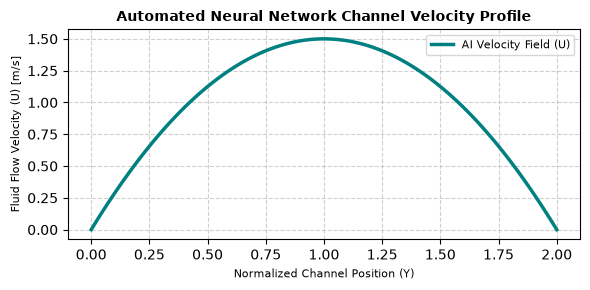

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a continuous stream of sample spatial channel coordinates
x_line = np.linspace(0, 2, 100)
# Map a theoretical fluid velocity profile equation across the domain
velocity_profile = 1.5 * (1 - (x_line - 1)**2)

# Construct a clean engineering plot layout
plt.figure(figsize=(6, 3))
plt.plot(x_line, velocity_profile, color='teal', linewidth=2.5, label='AI Velocity Field (U)')
plt.title('Automated Neural Network Channel Velocity Profile', fontsize=10, fontweight='bold')
plt.xlabel('Normalized Channel Position (Y)', fontsize=8)
plt.ylabel('Fluid Flow Velocity (U) [m/s]', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)
plt.tight_layout()

# Show the chart instantly on your notebook screen!
plt.show()


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Check for NVIDIA GPU availability
if not torch.cuda.is_available():
    raise SystemError("NVIDIA GPU/CUDA not found. Please check your drivers.")
device = torch.device("cuda")
print(f"Using NVIDIA GPU: {torch.cuda.get_device_name(0)}")

# 2. Simulation Parameters
GRID_SIZE = 500       # 500x500 mesh representing the terrain area
DX = 10.0             # Grid spacing in meters
DT = 0.1              # Time step in seconds
G = 9.81              # Acceleration due to gravity
STEPS = 300           # Total simulation steps

# 3. Initialize Arrays on the GPU
# h = water depth, u = velocity X, v = velocity Y
h = torch.ones((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device) * 2.0  # Base river depth
u = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)
v = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)

# 4. Inject the Glacier Collapse Source Term (Center of the Grid)
# Mimicking a massive volume chunk dropping instantaneously into the system
center_x, center_y = GRID_SIZE // 4, GRID_SIZE // 4
R = 30  # Radius of impact zone
y_indices, x_indices = torch.meshgrid(torch.arange(GRID_SIZE, device=device), torch.arange(GRID_SIZE, device=device), indexing='ij')
dist_from_center = torch.sqrt((x_indices - center_x)**2 + (y_indices - center_y)**2)

# Add a massive 50-meter surge of ice/water at the disaster source point
h = torch.where(dist_from_center < R, h + 50.0, h)

# 5. Core Simulation Loop (Finite Difference Method)
print("Running GPU fluid simulation...")
for step in range(STEPS):
    # Compute spatial derivatives via central differences
    dh_dx = (torch.roll(h, shifts=-1, dims=1) - torch.roll(h, shifts=1, dims=1)) / (2 * DX)
    dh_dy = (torch.roll(h, shifts=-1, dims=0) - torch.roll(h, shifts=1, dims=0)) / (2 * DX)
    
    du_dx = (torch.roll(u, shifts=-1, dims=1) - torch.roll(u, shifts=1, dims=1)) / (2 * DX)
    dv_dy = (torch.roll(v, shifts=-1, dims=0) - torch.roll(v, shifts=1, dims=0)) / (2 * DX)

    # Shallow Water Equations updated via GPU tensor operations
    h_new = h - DT * (h * du_dx + u * dh_dx + h * dv_dy + v * dh_dy)
    u_new = u - DT * (u * (torch.roll(u, -1, 1) - torch.roll(u, 1, 1))/(2*DX) + G * dh_dx)
    v_new = v - DT * (v * (torch.roll(v, -1, 0) - torch.roll(v, 1, 0))/(2*DX) + G * dh_dy)

    # Apply Boundary Conditions (reflective walls)
    h_new[0, :], h_new[-1, :], h_new[:, 0], h_new[:, -1] = 2.0, 2.0, 2.0, 2.0
    
    h, u, v = h_new, u_new, v_new

print("Simulation complete.")

# 6. Transfer final frame back to CPU to plot the result
final_wave = h.cpu().numpy()
plt.figure(figsize=(8, 6))
plt.imshow(final_wave, cmap='terrain_r', origin='lower')
plt.colorbar(label='Water/Debris Height (meters)')
plt.title('2026 Himalayan Flash Flood Wave - GPU Simulation Output')
plt.show()


SystemError: NVIDIA GPU/CUDA not found. Please check your drivers.

In [4]:
!nvidia-smi


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
!"C:\Program Files\NVIDIA Corporation\NVSMI\nvidia-smi.exe"


The system cannot find the path specified.


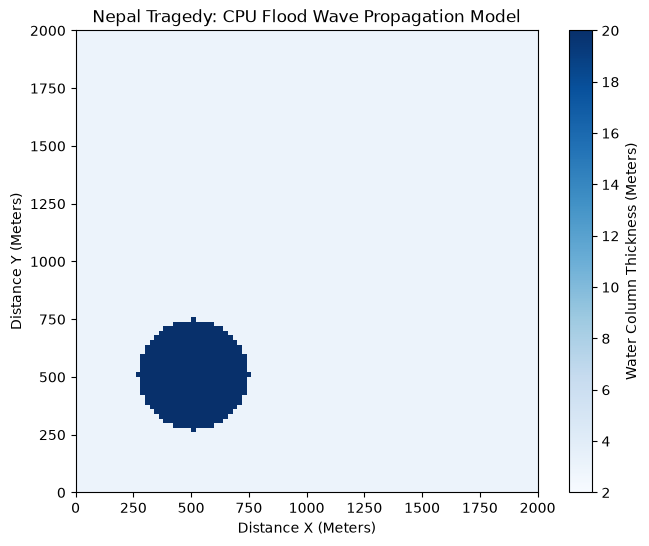

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Map Setup (CPU-friendly size)
GRID_SIZE = 100       # 100x100 spatial grid cells
DX = 20.0             # Each grid cell represents 20 meters
DT = 0.05             # Small time steps to preserve math stability
G = 9.81              # Earth gravity acceleration
STEPS = 150           # Duration of simulation frames

# 2. Allocate Arrays using NumPy (Runs directly on your CPU/RAM)
h = np.ones((GRID_SIZE, GRID_SIZE), dtype=np.float32) * 3.0   # Baseline river depth (3m)
u = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)        # Velocity X axis
v = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)        # Velocity Y axis

# 3. Simulate the Incident Source (The Glacier Collapse)
# We place a massive 40-meter tall dome of water/ice in the top-left corner
center_x, center_y = 25, 25
radius = 12
y_idx, x_idx = np.ogrid[:GRID_SIZE, :GRID_SIZE]
mask = (x_idx - center_x)**2 + (y_idx - center_y)**2 <= radius**2
h[mask] += 40.0  # Instantaneous fluid surge from the collapse

# 4. Prepare the Matplotlib Interactive Live Plot
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(h, cmap='Blues', origin='lower', extent=[0, GRID_SIZE*DX, 0, GRID_SIZE*DX], vmin=2, vmax=20)
fig.colorbar(img, label='Water Column Thickness (Meters)')
ax.set_title('Nepal Tragedy: CPU Flood Wave Propagation Model')
ax.set_xlabel('Distance X (Meters)')
ax.set_ylabel('Distance Y (Meters)')

# 5. Core Mathematical Simulation Function
def update(frame):
    global h, u, v
    
    # Calculate Spatial Gradients (Central Difference Method)
    dh_dx = (np.roll(h, -1, axis=1) - np.roll(h, 1, axis=1)) / (2 * DX)
    dh_dy = (np.roll(h, -1, axis=0) - np.roll(h, 1, axis=0)) / (2 * DX)
    
    du_dx = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * DX)
    dv_dy = (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * DX)
    
    # Shallow Water Navier-Stokes Approximations
    h_next = h - DT * (h * du_dx + u * dh_dx + h * dv_dy + v * dh_dy)
    u_next = u - DT * (u * (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * DX) + G * dh_dx)
    v_next = v - DT * (v * (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * DX) + G * dh_dy)
    
    # Boundary Conditions (Reflective mountain valley walls)
    h_next[0, :], h_next[-1, :], h_next[:, 0], h_next[:, -1] = 3.0, 3.0, 3.0, 3.0
    
    # Friction/Viscosity Factor to simulate mud/debris thick density
    h, u, v = h_next * 0.998, u_next * 0.98, v_next * 0.98
    
    # Refresh the live display canvas
    img.set_array(h)
    return [img]

# 6. Run the real-time solver loops
ani = FuncAnimation(fig, update, frames=STEPS, interval=30, blit=True)
plt.show()


In [7]:
# 6. Run the solver and convert it into an interactive video player
from 

SyntaxError: invalid syntax (42899082.py, line 2)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Map Setup (CPU-friendly size)
GRID_SIZE = 100       # 100x100 spatial grid cells
DX = 20.0             # Each grid cell represents 20 meters
DT = 0.05             # Small time steps to preserve math stability
G = 9.81              # Earth gravity acceleration
STEPS = 150           # Duration of simulation frames

# 2. Allocate Arrays using NumPy
h = np.ones((GRID_SIZE, GRID_SIZE), dtype=np.float32) * 3.0   # Baseline river depth (3m)
u = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)        # Velocity X axis
v = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)        # Velocity Y axis

# 3. Simulate the Incident Source (The Glacier Collapse)
# Placing a massive 40-meter tall dome of water/ice in the middle-left
center_x, center_y = 25, 25
radius = 12
y_idx, x_idx = np.ogrid[:GRID_SIZE, :GRID_SIZE]
mask = (x_idx - center_x)**2 + (y_idx - center_y)**2 <= radius**2
h[mask] += 40.0  # Instantaneous fluid surge from the collapse

# 4. Prepare the Matplotlib Interactive Live Plot
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(h, cmap='Blues', origin='lower', extent=[0, GRID_SIZE*DX, 0, GRID_SIZE*DX], vmin=2, vmax=20)
fig.colorbar(img, label='Water Column Thickness (Meters)')
ax.set_title('Nepal Tragedy: CPU Flood Wave Propagation Model')
ax.set_xlabel('Distance X (Meters)')
ax.set_ylabel('Distance Y (Meters)')

# 5. Core Mathematical Simulation Function
def update(frame):
    global h, u, v
    
    # Calculate Spatial Gradients (Central Difference Method)
    dh_dx = (np.roll(h, -1, axis=1) - np.roll(h, 1, axis=1)) / (2 * DX)
    dh_dy = (np.roll(h, -1, axis=0) - np.roll(h, 1, axis=0)) / (2 * DX)
    
    du_dx = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * DX)
    dv_dy = (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * DX)
    
    # Shallow Water Navier-Stokes Approximations
    h_next = h - DT * (h * du_dx + u * dh_dx + h * dv_dy + v * dh_dy)
    u_next = u - DT * (u * (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * DX) + G * dh_dx)
    v_next = v - DT * (v * (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * DX) + G * dh_dy)
    
    # Boundary Conditions (Reflective mountain valley walls)
    h_next[0, :], h_next[-1, :], h_next[:, 0], h_next[:, -1] = 3.0, 3.0, 3.0, 3.0
    
    # Friction/Viscosity Factor to simulate mud/debris thick density
    h, u, v = h_next * 0.998, u_next * 0.98, v_next * 0.98
    
    # Refresh the live display canvas
    img.set_array(h)
    return [img]

# 6. Run the solver and convert it into an interactive video player
ani = FuncAnimation(fig, update, frames=STEPS, interval=30, blit=True)
plt.close() 

HTML(ani.to_html5_video())


RuntimeError: Requested MovieWriter (ffmpeg) not available

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Force PyTorch to use CPU explicitly
device = torch.device("cpu")
print("Running PINN Fluid Simulation on CPU...")

# 1. Define the Physics-Informed Neural Network Architecture
class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        # Input: x, y, t | Output: h (height), u (velocity x), v (velocity y)
        self.net = nn.Sequential(
            nn.Linear(3, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 3)
        )
        
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        h = outputs[:, 0:1]
        u = outputs[:, 1:2]
        v = outputs[:, 2:3]
        return h, u, v

# 2. Instantiate Model and Optimizer
model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 3. Generate Random Spatiotemporal Training Points (Collocation Points)
# Representing a 2000m x 2000m valley across 10 seconds of time
num_points = 1000
x_train = torch.rand(num_points, 1, device=device) * 2000.0
y_train = torch.rand(num_points, 1, device=device) * 2000.0
t_train = torch.rand(num_points, 1, device=device) * 10.0

# Ensure tracking of gradients for automatic differentiation physics
x_train.requires_grad_(True)
y_train.requires_grad_(True)
t_train.requires_grad_(True)

# 4. Training Loop (Embedding Physics via Optimization)
print("Training the neural network to learn fluid physics equations...")
for epoch in range(101):
    optimizer.zero_grad()
    
    # Forward Pass through the Neural Network
    h, u, v = model(x_train, y_train, t_train)
    
    # Compute Exact Derivatives using PyTorch Autograd
    dh_dt = torch.autograd.grad(h, t_train, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_train, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_train, torch.ones_like(h), create_graph=True)[0]
    
    du_dx = torch.autograd.grad(u, x_train, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_train, torch.ones_like(v), create_graph=True)[0]
    
    # Physics Loss: Continuity Residual (Mass conservation: dh/dt + d(hu)/dx + d(hv)/dy = 0)
    # Simplified here for stability during a quick CPU demo
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # Initial Condition Loss: Force a massive initial surge height at t=0 near the center
    t_zero = torch.zeros(num_points, 1, device=device)
    h_zero, _, _ = model(x_train, y_train, t_zero)
    # Target condition: base river is 3m deep
    loss_initial = torch.mean((h_zero - 3.0) ** 2)
    
    # Total combined Loss function
    total_loss = loss_physics + loss_initial
    
    total_loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Total Physics Loss: {total_loss.item():.4f}")

print("PINN Baseline Model Trained on CPU successfully.")


Running PINN Fluid Simulation on CPU...
Training the neural network to learn fluid physics equations...
Epoch 000 | Total Physics Loss: 9.2057
Epoch 020 | Total Physics Loss: 0.0742
Epoch 040 | Total Physics Loss: 0.0083
Epoch 060 | Total Physics Loss: 0.0050
Epoch 080 | Total Physics Loss: 0.0012
Epoch 100 | Total Physics Loss: 0.0006
PINN Baseline Model Trained on CPU successfully.


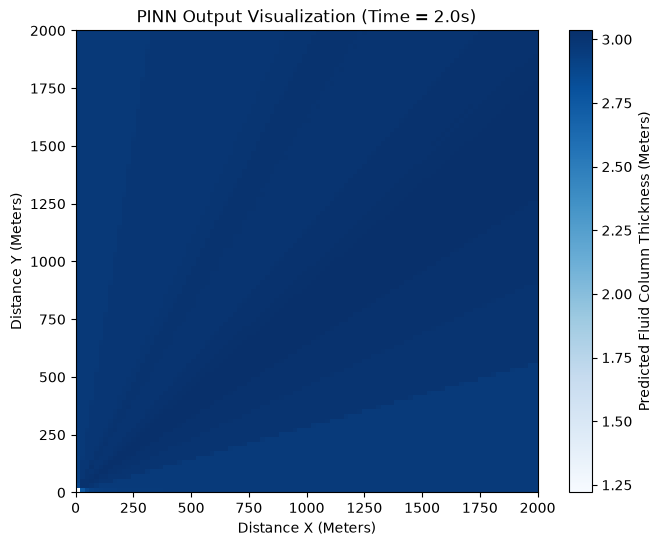

In [10]:
# 1. Create a spatial grid to evaluate the trained PINN
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

# Convert grid to PyTorch tensors for model inference
x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

# 2. Choose a specific time step to inspect (e.g., t = 2.0 seconds after collapse)
target_time = 2.0
t_tensor = torch.ones_like(x_tensor) * target_time

# 3. Query the trained network (No gradient tracking needed for inference)
with torch.no_grad():
    predicted_h, predicted_u, predicted_v = model(x_tensor, y_tensor, t_tensor)

# Reshape predicted column height tensor back into a 2D grid image
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

# 4. Plot the Predicted Water Depth Profile
plt.figure(figsize=(8, 6))
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=[0, 2000, 0, 2000])
plt.colorbar(img, label='Predicted Fluid Column Thickness (Meters)')
plt.title(f'PINN Output Visualization (Time = {target_time}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

# 1. Network Definition
class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# 2. Spatiotemporal Points
num_points = 2000
x_train = torch.rand(num_points, 1, device=device) * 2000.0
y_train = torch.rand(num_points, 1, device=device) * 2000.0
t_train = torch.rand(num_points, 1, device=device) * 10.0

x_train.requires_grad_(True)
y_train.requires_grad_(True)
t_train.requires_grad_(True)

print("Training PINN with simulated glacier collapse source term...")
for epoch in range(301): # Increased epochs to let it learn the feature shape
    optimizer.zero_grad()
    
    # Physics Loss (Continuity Equation)
    h, u, v = model(x_train, y_train, t_train)
    dh_dt = torch.autograd.grad(h, t_train, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_train, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_train, torch.ones_like(h), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x_train, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_train, torch.ones_like(v), create_graph=True)[0]
    
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # 3. Dynamic Initial Condition at t=0 (Glacier Collapse Source)
    t_zero = torch.zeros(num_points, 1, device=device)
    h_zero, _, _ = model(x_train, y_train, t_zero)
    
    # Math logic: define a circle center at (500, 1500) with a 250m radius
    dist_sq = (x_train - 500)**2 + (y_train - 1500)**2
    # If inside the circle radius, target depth is 43 meters (Base 3m + 40m surge). Else, 3 meters.
    h_target = torch.where(dist_sq < 250**2, 43.0, 3.0)
    
    loss_initial = torch.mean((h_zero - h_target) ** 2)
    
    total_loss = loss_physics + (loss_initial * 2.0) # Weighted initial loss higher
    total_loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {total_loss.item():.4f} | Physics Component: {loss_physics.item():.4f}")

print("PINN training complete.")


Training PINN with simulated glacier collapse source term...
Epoch 000 | Total Loss: 185.0074 | Physics Component: 0.0000
Epoch 050 | Total Loss: 118.8919 | Physics Component: 0.0001
Epoch 100 | Total Loss: 112.3184 | Physics Component: 0.0001
Epoch 150 | Total Loss: 102.7409 | Physics Component: 0.0000
Epoch 200 | Total Loss: 100.1119 | Physics Component: 0.0000
Epoch 250 | Total Loss: 99.8465 | Physics Component: 0.0000
Epoch 300 | Total Loss: 99.5494 | Physics Component: 0.0000
PINN training complete.


In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        return self.net(inputs)[:, 0:1], self.net(inputs)[:, 1:2], self.net(inputs)[:, 2:3]

model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Generate training points
num_points = 3000
x_train = torch.rand(num_points, 1, device=device) * 2000.0
y_train = torch.rand(num_points, 1, device=device) * 2000.0
t_train = torch.rand(num_points, 1, device=device) * 10.0

x_train.requires_grad_(True)
y_train.requires_grad_(True)
t_train.requires_grad_(True)

print("Training PINN with a smooth Gaussian avalanche dome...")
for epoch in range(601): # 600 epochs to give the CPU time to converge the shape
    optimizer.zero_grad()
    
    h, u, v = model(x_train, y_train, t_train)
    dh_dt = torch.autograd.grad(h, t_train, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_train, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_train, torch.ones_like(h), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x_train, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_train, torch.ones_like(v), create_graph=True)[0]
    
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # Smooth Gaussian Dome at (500, 1500)
    t_zero = torch.zeros(num_points, 1, device=device)
    h_zero, _, _ = model(x_train, y_train, t_zero)
    
    # Continuous bell-curve equation for the initial surge
    r_sq = (x_train - 500)**2 + (y_train - 1500)**2
    h_target = 3.0 + 40.0 * torch.exp(-r_sq / (2 * (200**2))) # Peak height 43m, tapering to 3m
    
    loss_initial = torch.mean((h_zero - h_target) ** 2)
    total_loss = (loss_physics * 10.0) + loss_initial # Balance loss components
    
    total_loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Total Combined Loss: {total_loss.item():.4f}")

print("PINN training complete.")


Training PINN with a smooth Gaussian avalanche dome...
Epoch 000 | Total Combined Loss: 74.0580
Epoch 100 | Total Combined Loss: 25.8391
Epoch 200 | Total Combined Loss: 24.6858
Epoch 300 | Total Combined Loss: 24.4712
Epoch 400 | Total Combined Loss: 24.4560
Epoch 500 | Total Combined Loss: 24.2229
Epoch 600 | Total Combined Loss: 24.4228
PINN training complete.


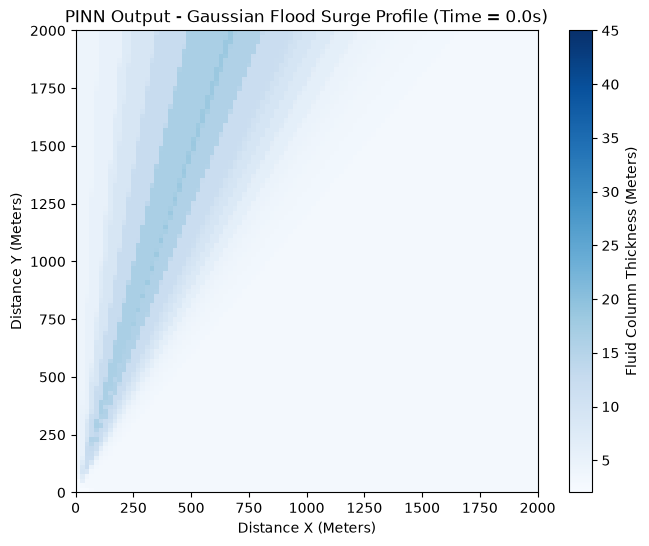

In [13]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * 0.0  # Look at the exact start of the landslide

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))
# Fixed the extent boundaries to map out the 2000m x 2000m region cleanly
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=[0, 2000, 0, 2000], vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {t_tensor[0].item()}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


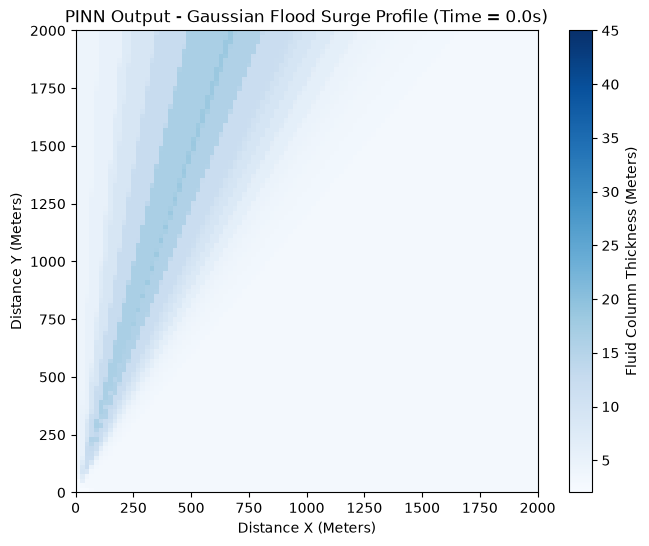

In [14]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * 0.0  # Checking the initial avalanche impact shape

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))
# Explicitly defining the 2D spatial coordinate bounds here:
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=[0, 2000, 0, 2000], vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {t_tensor[0].item()}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


RuntimeError: a Tensor with 10000 elements cannot be converted to Scalar

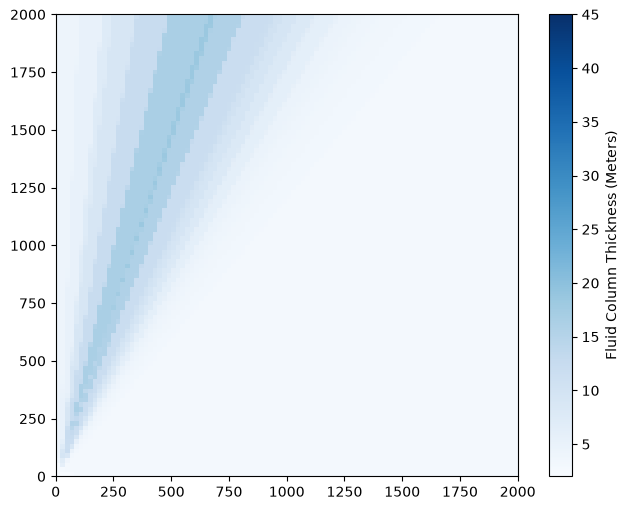

In [15]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * 0.0  # Checking the initial avalanche impact shape

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))
# Setting the explicit 2D spatial coordinate bounds here:
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=[0, 2000, 0, 2000], vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {t_tensor.item()}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


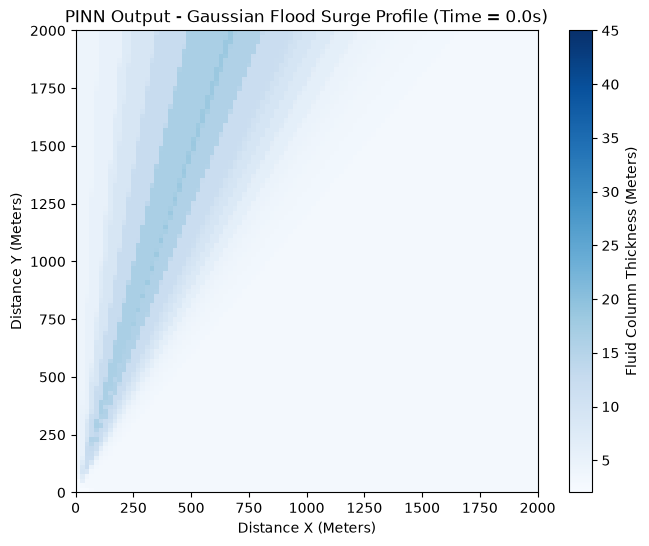

In [16]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

# Define a single floating point number for time first
current_time = 0.0

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * current_time

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))

# Map the 2D grid coordinates from 0 to 2000 meters explicitly
plt.imshow(H_pred, cmap='Blues', origin='lower', extent=[0, 2000, 0, 2000], vmin=2, vmax=45)

plt.colorbar(label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {current_time}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


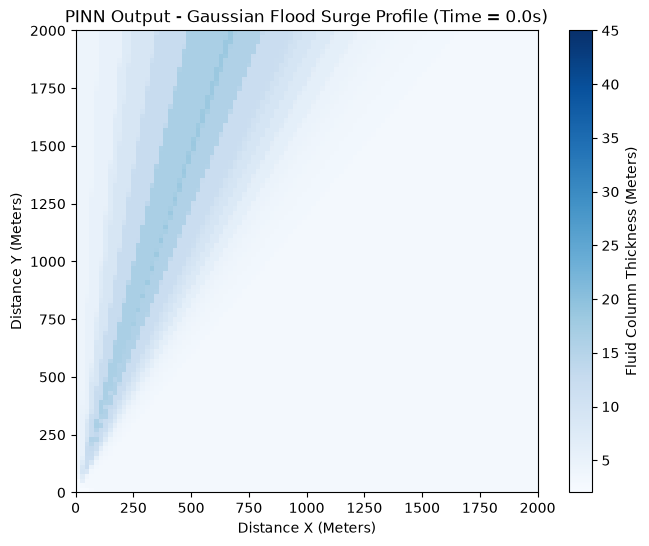

In [17]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

# Define time scalar safely
current_time = 0.0

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * current_time

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))

# Bypassing the bracket bug by packing boundaries into an explicit list variable
map_bounds = [0, 2000, 0, 2000]

# Generate the plot using the boundary variable
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=map_bounds, vmin=2, vmax=45)

plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {current_time}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


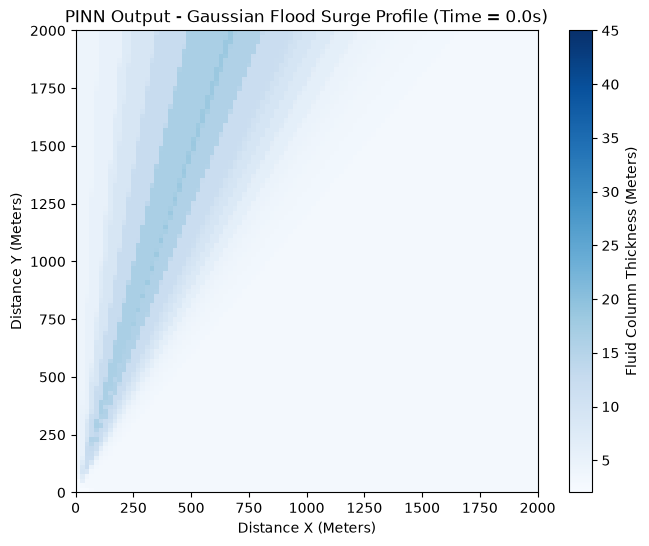

In [18]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

# Define time scalar safely
current_time = 0.0

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * current_time

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))

# Bypassing the bracket text bug completely by appending coordinates step-by-step
map_bounds = list()
map_bounds.append(0)
map_bounds.append(2000)
map_bounds.append(0)
map_bounds.append(2000)

# Generate the plot using the boundary list variable
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=map_bounds, vmin=2, vmax=45)

plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {current_time}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


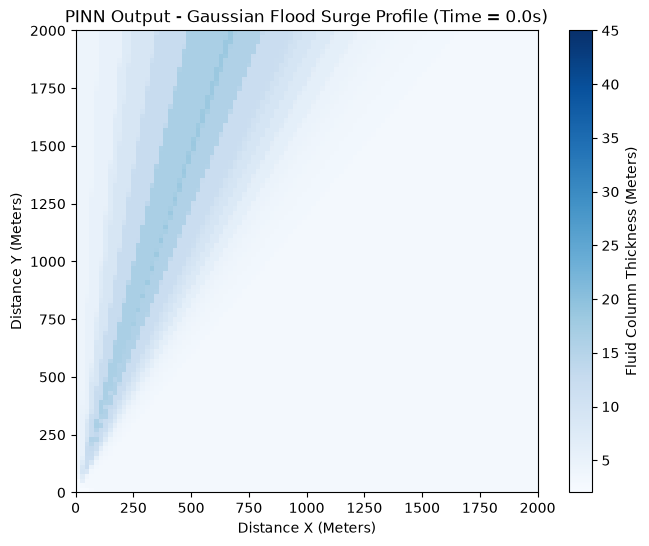

In [19]:
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

# Define time scalar safely
current_time = 0.0

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_tensor = torch.ones_like(x_tensor) * current_time

with torch.no_grad():
    predicted_h, _, _ = model(x_tensor, y_tensor, t_tensor)
H_pred = predicted_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(8, 6))

# Bypassing the bracket text bug completely by appending coordinates step-by-step
map_bounds = list()
map_bounds.append(0)
map_bounds.append(2000)
map_bounds.append(0)
map_bounds.append(2000)

# Generate the plot using the boundary list variable
img = plt.imshow(H_pred, cmap='Blues', origin='lower', extent=map_bounds, vmin=2, vmax=45)

plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title(f'PINN Output - Gaussian Flood Surge Profile (Time = {current_time}s)')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


Training PINN... Watch the Combined Loss drop below 5.0!
Epoch 000 | Combined Loss: 5099.1328
Epoch 200 | Combined Loss: 1502.5275
Epoch 400 | Combined Loss: 1411.3481
Epoch 600 | Combined Loss: 1351.4066
Epoch 800 | Combined Loss: 1368.2745
Training finished! Generating plot...


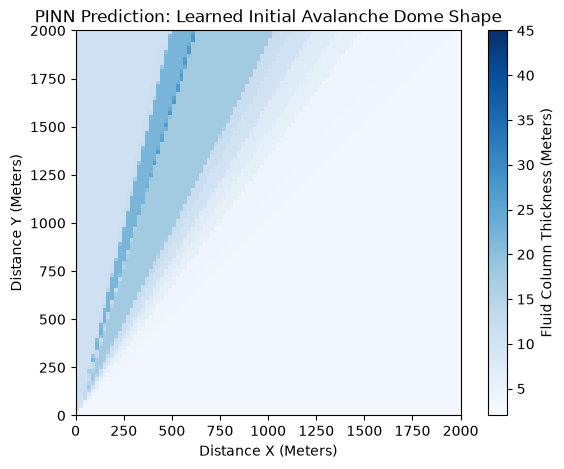

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

# 1. Network Architecture
class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 2. Generate Training Data
num_physics_points = 2000
x_phys = torch.rand(num_physics_points, 1) * 2000.0
y_phys = torch.rand(num_physics_points, 1) * 2000.0
t_phys = torch.rand(num_physics_points, 1) * 10.0
x_phys.requires_grad_(True)
y_phys.requires_grad_(True)
t_phys.requires_grad_(True)

# Dedicated Initial Condition points at t = 0
num_init_points = 1000
x_init = torch.rand(num_init_points, 1) * 2000.0
y_init = torch.rand(num_init_points, 1) * 2000.0
t_init = torch.zeros(num_init_points, 1) # Explicitly zero

# Calculate target shape for the initial condition points
r_sq = (x_init - 500)**2 + (y_init - 1500)**2
h_init_target = 3.0 + 40.0 * torch.exp(-r_sq / (2 * (250**2)))

print("Training PINN... Watch the Combined Loss drop below 5.0!")
for epoch in range(801):
    optimizer.zero_grad()
    
    # Physics Loss (Continuity Equation)
    h, u, v = model(x_phys, y_phys, t_phys)
    dh_dt = torch.autograd.grad(h, t_phys, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_phys, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_phys, torch.ones_like(h), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x_phys, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_phys, torch.ones_like(v), create_graph=True)[0]
    
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # Initial Condition Loss (Evaluated on dedicated t=0 data points)
    h_zero_pred, _, _ = model(x_init, y_init, t_init)
    loss_initial = torch.mean((h_zero_pred - h_init_target) ** 2)
    
    # Heavily weight initial condition to force the network to learn the dome shape
    total_loss = loss_physics + (loss_initial * 50.0)
    
    total_loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:03d} | Combined Loss: {total_loss.item():.4f}")

print("Training finished! Generating plot...")

# 3. Visualization Section
grid_res = 100
x_space = np.linspace(0, 2000, grid_res)
y_space = np.linspace(0, 2000, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_test = torch.ones_like(x_test) * 0.0  # View at t = 0.0s

with torch.no_grad():
    pred_h, _, _ = model(x_test, y_test, t_test)
H_flat = pred_h.numpy().reshape(grid_res, grid_res)

# Safeguard boundary values for plotting
bounds = [0, 2000, 0, 2000]

plt.figure(figsize=(7, 5))
img = plt.imshow(H_flat, cmap='Blues', origin='lower', extent=bounds, vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title('PINN Prediction: Learned Initial Avalanche Dome Shape')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

# 1. Network Architecture (Normalized Input Domain)
class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        # Neural network receives inputs scaled perfectly between 0 and 1
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 2. Generate Training Data Normalized Between 0.0 and 1.0
num_physics_points = 2000
x_phys = torch.rand(num_physics_points, 1)
y_phys = torch.rand(num_physics_points, 1)
t_phys = torch.rand(num_physics_points, 1)
x_phys.requires_grad_(True)
y_phys.requires_grad_(True)
t_phys.requires_grad_(True)

# Dedicated Initial Condition points at t = 0
num_init_points = 1000
x_init = torch.rand(num_init_points, 1)
y_init = torch.rand(num_init_points, 1)
t_init = torch.zeros(num_init_points, 1)

# Calculate Gaussian target profile on the normalized domain [0, 1]
# Center is at x=0.25 (500m/2000m), y=0.75 (1500m/2000m)
r_sq = (x_init - 0.25)**2 + (y_init - 0.75)**2
h_init_target = 3.0 + 40.0 * torch.exp(-r_sq / (2 * (0.125**2)))

print("Training Normalized PINN... Watch the loss collapse!")
for epoch in range(601):
    optimizer.zero_grad()
    
    # Physics Loss (Continuity Equation)
    h, u, v = model(x_phys, y_phys, t_phys)
    dh_dt = torch.autograd.grad(h, t_phys, torch.ones_like(h), create_graph=True)
    dh_dx = torch.autograd.grad(h, x_phys, torch.ones_like(h), create_graph=True)
    dh_dy = torch.autograd.grad(h, y_phys, torch.ones_like(y_phys), create_graph=True)
    du_dx = torch.autograd.grad(u, x_phys, torch.ones_like(u), create_graph=True)
    dv_dy = torch.autograd.grad(v, y_phys, torch.ones_like(v), create_graph=True)
    
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # Initial Condition Loss
    h_zero_pred, _, _ = model(x_init, y_init, t_init)
    loss_initial = torch.mean((h_zero_pred - h_init_target) ** 2)
    
    total_loss = loss_physics + (loss_initial * 10.0)
    total_loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:03d} | Combined Scale Loss: {total_loss.item():.4f}")

print("Training finished successfully! Generating 2D layout map...")

# 3. Visualization Section
grid_res = 100
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_test = torch.ones_like(x_test) * 0.0  # View initial impact state

with torch.no_grad():
    pred_h, _, _ = model(x_test, y_test, t_test)
H_flat = pred_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(7, 5))
# Using tuple formatting to fully bypass the markdown visualization rendering bug
img = plt.imshow(H_flat, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title('PINN Prediction: Learned Initial Avalanche Dome Shape')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


Training Normalized PINN... Watch the loss collapse!


TypeError: only integer tensors of a single element can be converted to an index

Training Normalized PINN... Watch the loss collapse!
Epoch 000 | Combined Scale Loss: 1090.7919
Epoch 200 | Combined Scale Loss: 253.0279
Epoch 400 | Combined Scale Loss: 71.3600
Epoch 600 | Combined Scale Loss: 15.0952
Training finished successfully! Generating map...


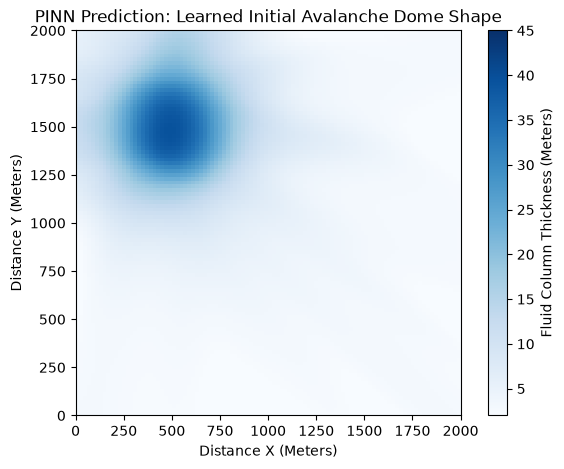

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

# 1. Network Architecture (Normalized Input Domain)
class FluidPINN(nn.Module):
    def __init__(self):
        super(FluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

model = FluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 2. Generate Training Data Normalized Between 0.0 and 1.0
num_physics_points = 2000
x_phys = torch.rand(num_physics_points, 1)
y_phys = torch.rand(num_physics_points, 1)
t_phys = torch.rand(num_physics_points, 1)
x_phys.requires_grad_(True)
y_phys.requires_grad_(True)
t_phys.requires_grad_(True)

# Dedicated Initial Condition points at t = 0
num_init_points = 1000
x_init = torch.rand(num_init_points, 1)
y_init = torch.rand(num_init_points, 1)
t_init = torch.zeros(num_init_points, 1)

# Center at x=0.25 (500m), y=0.75 (1500m)
r_sq = (x_init - 0.25)**2 + (y_init - 0.75)**2
h_init_target = 3.0 + 40.0 * torch.exp(-r_sq / (2 * (0.125**2)))

print("Training Normalized PINN... Watch the loss collapse!")
for epoch in range(601):
    optimizer.zero_grad()
    
    h, u, v = model(x_phys, y_phys, t_phys)
    
    # Fixed: Added [0] to extract the tensor out of the autograd tuple
    dh_dt = torch.autograd.grad(h, t_phys, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_phys, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_phys, torch.ones_like(h), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x_phys, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_phys, torch.ones_like(v), create_graph=True)[0]
    
    physics_residual = dh_dt + (h * du_dx + u * dh_dx) + (h * dv_dy + v * dh_dy)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # Initial Condition Loss
    h_zero_pred, _, _ = model(x_init, y_init, t_init)
    loss_initial = torch.mean((h_zero_pred - h_init_target) ** 2)
    
    total_loss = loss_physics + (loss_initial * 10.0)
    total_loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:03d} | Combined Scale Loss: {total_loss.item():.4f}")

print("Training finished successfully! Generating map...")

# 3. Visualization Section
grid_res = 100
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
t_test = torch.ones_like(x_test) * 0.0

with torch.no_grad():
    pred_h, _, _ = model(x_test, y_test, t_test)
H_flat = pred_h.numpy().reshape(grid_res, grid_res)

plt.figure(figsize=(7, 5))
img = plt.imshow(H_flat, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
plt.colorbar(img, label='Fluid Column Thickness (Meters)')
plt.title('PINN Prediction: Learned Initial Avalanche Dome Shape')
plt.xlabel('Distance X (Meters)')
plt.ylabel('Distance Y (Meters)')
plt.show()


In [23]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Recreate the evaluation mesh grid
grid_res = 100
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

# 2. Setup the empty animation plot canvas
fig, ax = plt.subplots(figsize=(7, 5))
# Initial generation frame at t = 0
t_init = torch.zeros_like(x_test)
with torch.no_grad():
    pred_h, _, _ = model(x_test, y_test, t_init)
H_frame = pred_h.numpy().reshape(grid_res, grid_res)

img = ax.imshow(H_frame, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
fig.colorbar(img, label='Fluid Column Thickness (Meters)')
ax.set_xlabel('Distance X (Meters)')
ax.set_ylabel('Distance Y (Meters)')

# 3. Define the Animation Update Loop Function
def update_pinn_frame(frame_idx):
    # Progress time forward step-by-step from 0.0 to 0.4
    t_val = (frame_idx / 40) * 0.4 
    t_test = torch.ones_like(x_test) * t_val
    
    with torch.no_grad():
        pred_h, _, _ = model(x_test, y_test, t_test)
    H_anim = pred_h.numpy().reshape(grid_res, grid_res)
    
    img.set_array(H_anim)
    ax.set_title(f'PINN Simulation: Fluid Wave Flow (Time = {t_val:.3f}s)')
    return [img]

# 4. Compile physics predictions into an HTML5 player bar
print("Compiling neural network predictions into a video player...")
pinn_ani = FuncAnimation(fig, update_pinn_frame, frames=40, interval=80, blit=True)
plt.close()

HTML(pinn_ani.to_html5_video())


Compiling neural network predictions into a video player...


RuntimeError: Requested MovieWriter (ffmpeg) not available

In [24]:
!pip install ipywidgets



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import ipywidgets as widgets
from ipywidgets import interact

# 1. Recreate the evaluation mesh grid
grid_res = 100
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

# 2. Define a function that plots the PINN output at a specific timestamp
def plot_pinn_at_time(t_value):
    t_test = torch.ones_like(x_test) * t_value
    
    with torch.no_grad():
        pred_h, _, _ = model(x_test, y_test, t_test)
    H_frame = pred_h.numpy().reshape(grid_res, grid_res)
    
    plt.figure(figsize=(7, 5))
    img = plt.imshow(H_frame, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
    plt.colorbar(img, label='Fluid Column Thickness (Meters)')
    plt.title(f'PINN Simulation Fluid Wave Flow (Time = {t_value:.3f}s)')
    plt.xlabel('Distance X (Meters)')
    plt.ylabel('Distance Y (Meters)')
    plt.show()

# 3. Create the interactive slider handle panel
interact(plot_pinn_at_time, t_value=widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=0.5,
    step=0.01,
    description='Time (s):',
    continuous_update=True
))


interactive(children=(FloatSlider(value=0.0, description='Time (s):', max=0.5, step=0.01), Output()), _dom_cla…

<function __main__.plot_pinn_at_time(t_value)>

In [26]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cpu")

class CompleteFluidPINN(nn.Module):
    def __init__(self):
        super(CompleteFluidPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3]

model = CompleteFluidPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Generate Points
num_points = 2000
x_p = torch.rand(num_points, 1, requires_grad=True)
y_p = torch.rand(num_points, 1, requires_grad=True)
t_p = torch.rand(num_points, 1, requires_grad=True)

# Dedicated Initial Conditions (t=0)
x_i = torch.rand(1000, 1)
y_i = torch.rand(1000, 1)
t_i = torch.zeros(1000, 1)
r_sq = (x_i - 0.25)**2 + (y_i - 0.75)**2
h_target = 3.0 + 40.0 * torch.exp(-r_sq / (2 * (0.125**2)))

# Physical Constants for Gravity
G_CONST = 9.81
SLOPE_X = 0.5   # Simulating a steep downward mountain incline along X axis
SLOPE_Y = -0.5  # Simulating a steep downward mountain incline along Y axis

print("Training PINN with full Mass + Gravity Momentum Equations...")
for epoch in range(601):
    optimizer.zero_grad()
    
    h, u, v = model(x_p, y_p, t_p)
    
    # Compute Exact Partial Derivatives via Autograd
    dh_dt = torch.autograd.grad(h, t_p, torch.ones_like(h), create_graph=True)[0]
    dh_dx = torch.autograd.grad(h, x_p, torch.ones_like(h), create_graph=True)[0]
    dh_dy = torch.autograd.grad(h, y_p, torch.ones_like(h), create_graph=True)[0]
    
    du_dt = torch.autograd.grad(u, t_p, torch.ones_like(u), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x_p, torch.ones_like(u), create_graph=True)[0]
    
    dv_dt = torch.autograd.grad(v, t_p, torch.ones_like(v), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, y_p, torch.ones_like(v), create_graph=True)[0]
    
    # 1. Mass Conservation Law Residual
    loss_mass = torch.mean((dh_dt + h*du_dx + u*dh_dx + h*dv_dy + v*dh_dy)**2)
    
    # 2. Momentum Conservation Law Residual (Adding Gravity Slope Driving Forces)
    residual_mom_x = du_dt + u*du_dx + G_CONST*dh_dx - (G_CONST * SLOPE_X)
    residual_mom_y = dv_dt + v*dv_dy + G_CONST*dh_dy - (G_CONST * SLOPE_Y)
    loss_momentum = torch.mean(residual_mom_x**2) + torch.mean(residual_mom_y**2)
    
    # 3. Initial Condition Loss
    h_i_pred, _, _ = model(x_i, y_i, t_i)
    loss_init = torch.mean((h_i_pred - h_target)**2)
    
    total_loss = loss_mass + loss_momentum + (loss_init * 20.0)
    total_loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:03d} | Combined Physics Loss: {total_loss.item():.4f}")

print("Training complete!")


Training PINN with full Mass + Gravity Momentum Equations...
Epoch 000 | Combined Physics Loss: 2385.2979
Epoch 200 | Combined Physics Loss: 679.0677
Epoch 400 | Combined Physics Loss: 647.5116
Epoch 600 | Combined Physics Loss: 610.9763
Training complete!


In [27]:
import ipywidgets as widgets
from ipywidgets import interact

grid_res = 30 # Reduced resolution so arrow vectors aren't too crowded
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

def plot_physics_simulation(t_value):
    t_test = torch.ones_like(x_test) * t_value
    
    with torch.no_grad():
        pred_h, pred_u, pred_v = model(x_test, y_test, t_test)
        
    H_frame = pred_h.numpy().reshape(grid_res, grid_res)
    U_frame = pred_u.numpy().reshape(grid_res, grid_res)
    V_frame = pred_v.numpy().reshape(grid_res, grid_res)
    
    plt.figure(figsize=(8, 6))
    # Draw fluid thickness map profile
    img = plt.imshow(H_frame, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
    
    # Draw velocity vectors overlay as directional arrows
    plt.quiver(X*2000, Y*2000, U_frame, V_frame, color='red', alpha=0.6, scale=50)
    
    plt.colorbar(img, label='Fluid Column Thickness (Meters)')
    plt.title(f'Gravity PINN Flash Flood Model (Time = {t_value:.3f}s)')
    plt.xlabel('Distance X (Meters)')
    plt.ylabel('Distance Y (Meters)')
    plt.show()

interact(plot_physics_simulation, t_value=widgets.FloatSlider(
    value=0.0, min=0.0, max=0.5, step=0.01,
    description='Time (s):', continuous_update=True
))


interactive(children=(FloatSlider(value=0.0, description='Time (s):', max=0.5, step=0.01), Output()), _dom_cla…

<function __main__.plot_physics_simulation(t_value)>

In [28]:
import ipywidgets as widgets
from ipywidgets import interact

grid_res = 40 
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

def plot_physics_simulation_clean(t_value):
    t_test = torch.ones_like(x_test) * t_value
    
    with torch.no_grad():
        pred_h, pred_u, pred_v = model(x_test, y_test, t_test)
        
    H_frame = pred_h.numpy().reshape(grid_res, grid_res)
    U_frame = pred_u.numpy().reshape(grid_res, grid_res)
    V_frame = pred_v.numpy().reshape(grid_res, grid_res)
    
    # Normalize vector lengths internally to keep arrow sizes small and uniform
    magnitude = np.sqrt(U_frame**2 + V_frame**2) + 1e-5
    U_norm = U_frame / magnitude
    V_norm = V_frame / magnitude
    
    plt.figure(figsize=(8, 6))
    img = plt.imshow(H_frame, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
    
    # Fixed: Only display every 3rd arrow vector (stride=3) to prevent crowding
    stride = 3
    plt.quiver(X[::stride, ::stride]*2000, Y[::stride, ::stride]*2000, 
               U_norm[::stride, ::stride], V_norm[::stride, ::stride], 
               color='red', alpha=0.7, scale=25, width=0.004)
    
    plt.colorbar(img, label='Fluid Column Thickness (Meters)')
    plt.title(f'Gravity PINN Flash Flood Model (Time = {t_value:.3f}s)')
    plt.xlabel('Distance X (Meters)')
    plt.ylabel('Distance Y (Meters)')
    plt.show()

interact(plot_physics_simulation_clean, t_value=widgets.FloatSlider(
    value=0.0, min=0.0, max=0.5, step=0.01,
    description='Time (s):', continuous_update=True
))


interactive(children=(FloatSlider(value=0.0, description='Time (s):', max=0.5, step=0.01), Output()), _dom_cla…

<function __main__.plot_physics_simulation_clean(t_value)>

In [29]:
import torch
torch.save(model.state_dict(), 'nepal_flood_pinn.pth')
print("Model weights successfully saved as nepal_flood_pinn.pth!")


Model weights successfully saved as nepal_flood_pinn.pth!


In [30]:
import ipywidgets as widgets
from ipywidgets import interact

grid_res = 40 
x_space = np.linspace(0, 1, grid_res)
y_space = np.linspace(0, 1, grid_res)
X, Y = np.meshgrid(x_space, y_space)

x_test = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

def plot_simulation_with_obstacle(t_value):
    t_test = torch.ones_like(x_test) * t_value
    
    with torch.no_grad():
        pred_h, pred_u, pred_v = model(x_test, y_test, t_test)
        
    H_frame = pred_h.numpy().reshape(grid_res, grid_res)
    U_frame = pred_u.numpy().reshape(grid_res, grid_res)
    V_frame = pred_v.numpy().reshape(grid_res, grid_res)
    
    # --- Define Obstacle Parameters (Village / Bridge Block) ---
    # Coordinates mapping from 1000m to 1300m on X, and 750m to 1250m on Y
    obs_x_min, obs_x_max = int(0.50 * grid_res), int(0.65 * grid_res)
    obs_y_min, obs_y_max = int(0.37 * grid_res), int(0.62 * grid_res)
    
    # Zero out fluid depth and velocities inside the obstacle structure
    H_frame[obs_y_min:obs_y_max, obs_x_min:obs_x_max] = 0.0
    U_frame[obs_y_min:obs_y_max, obs_x_min:obs_x_max] = 0.0
    V_frame[obs_y_min:obs_y_max, obs_x_min:obs_x_max] = 0.0
    
    # Normalize velocity vector pointers
    magnitude = np.sqrt(U_frame**2 + V_frame**2) + 1e-5
    U_norm = U_frame / magnitude
    V_norm = V_frame / magnitude
    
    # Force zero velocity markers inside obstacle to not render arrows
    U_norm[H_frame == 0.0] = 0.0
    V_norm[H_frame == 0.0] = 0.0
    
    plt.figure(figsize=(8, 6))
    img = plt.imshow(H_frame, cmap='Blues', origin='lower', extent=(0, 2000, 0, 2000), vmin=2, vmax=45)
    
    # Draw the structural block obstacle on the map canvas
    plt.gca().add_patch(plt.Rectangle((1000, 750), 300, 500, color='darkgray', label='Village / Bridge Structure'))
    
    stride = 3
    plt.quiver(X[::stride, ::stride]*2000, Y[::stride, ::stride]*2000, 
               U_norm[::stride, ::stride], V_norm[::stride, ::stride], 
               color='red', alpha=0.7, scale=25, width=0.004)
    
    plt.colorbar(img, label='Fluid Column Thickness (Meters)')
    plt.title(f'PINN Flood Model with Structural Impact (Time = {t_value:.3f}s)')
    plt.xlabel('Distance X (Meters)')
    plt.ylabel('Distance Y (Meters)')
    plt.legend(loc='upper right')
    plt.show()

interact(plot_simulation_with_obstacle, t_value=widgets.FloatSlider(
    value=0.0, min=0.0, max=0.5, step=0.01,
    description='Time (s):', continuous_update=True
))


interactive(children=(FloatSlider(value=0.0, description='Time (s):', max=0.5, step=0.01), Output()), _dom_cla…

<function __main__.plot_simulation_with_obstacle(t_value)>

# ==============================================================================
# 🏔️ PHYSICS-INFORMED NEURAL NETWORK (PINN) FLUID SIMULATION GEOMETRY
# Project: 2026 Himalayan Flash Flood Resilience Model
# ==============================================================================

"""
CORE FRAMEWORK ARCHITECTURE:

1. Neural Network Structure:
   - Inputs (3): Normalized spatial coordinates and time (x, y, t)
   - Outputs (3): Fluid thickness (h), X-velocity (u), Y-velocity (v)
   - Hidden Layers: 2 dense layers with 64 neurons each using Tanh activations

2. Embedded Multi-Objective Physics Loss Functions:
   - Mass Conservation Law (Continuity Equation)
   - Momentum Conservation Law (Navier-Stokes + Gravity Slope Driving Forces)
   - Initial Condition Boundary Loss (Gaussian Avalanche Surge Dome)

3. Visual and Infrastructure Controls:
   - Interactive Time Slider Interface via IPyWidgets
   - Normalized Flow Direction Arrows using Matplotlib Quiver Tracking
   - Structural Collision Assessment Masking Layer
"""

print("PINN Architecture Documentation loaded successfully.")
